# Разведывательный анализ данных

Цель этого ноутбука — проверить качество исходных данных, временную структуру и возможные источники утечки до построения моделей. Здесь нет обучения и подбора признаков.

## Что проверяем

- размеры, типы и ключи таблиц;
- баланс целевого класса;
- пропуски и выбросы;
- события за границами суточных окон;
- показ капчи и другие признаки, недоступные на момент решения;
- дубликаты и одинаковые временные метки;
- хронологию train и test;
- сдвиг распределений между train и test;
- повторяемость объявлений и других сущностей во времени.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from artifacts import configure_logging
from config import ARTIFACT_DIR, DATA_DIR, RANDOM_SEED, REPORT_DIR
from data import load_metadata, load_or_prepare_events, load_raw_events

configure_logging()
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
FIGURE_DIR = REPORT_DIR / "figures" / "eda"
TABLE_DIR = REPORT_DIR / "tables" / "eda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED

42

## Загрузка данных

Подготовленные события загружаются из кеша. Если кеша нет, он строится один раз и сохраняется в `artifacts/prepared/`.

In [2]:
data = load_metadata()
train = data.train
test = data.test
metadata = data.metadata
events = load_or_prepare_events(metadata)

data_overview = pd.DataFrame([
    {"table": "train", "rows": len(train), "columns": train.shape[1]},
    {"table": "test", "rows": len(test), "columns": test.shape[1]},
    {"table": "events_in_window", "rows": len(events), "columns": events.shape[1]},
])
data_overview

14:54:58 | INFO | data | Метаданные загружены: train=11091, test=4909, ботов=899
14:54:58 | INFO | artifacts | События внутри окон: кеш, строк=288126, колонок=18


,table,rows,columns
0,train,11091,5
1,test,4909,4
2,events_in_window,288126,18


## Целевая переменная

In [3]:
target_summary = train["target"].value_counts().sort_index().rename_axis("target").to_frame("count")
target_summary["share"] = target_summary["count"] / len(train)
target_summary

,count,share
target,,
0,10192,0.918943
1,899,0.081057


14:54:58 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:54:58 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


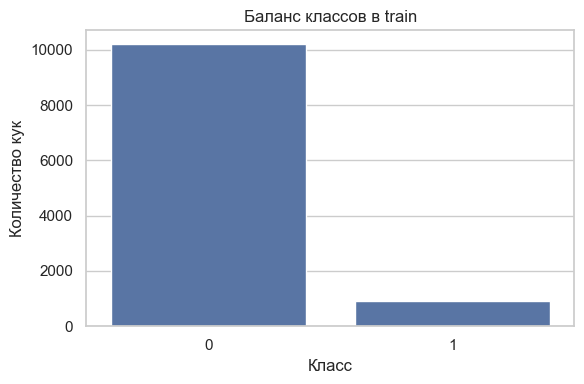

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train, x="target", ax=ax)
ax.set_title("Баланс классов в train")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество кук")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_balance.png", dpi=160, bbox_inches="tight")
plt.show()

## Пропуски

Для событий пропуск не всегда означает ошибку. Например, координаты курсора доступны не для всех платформ, а поисковый запрос относится только к поисковым событиям. Поэтому смотрим не только общую долю, но и долю внутри типов событий.

In [5]:
metadata_missing = pd.DataFrame({
    "train": train.isna().mean(),
    "test": test.isna().mean(),
}).sort_values("train", ascending=False)
metadata_missing

,train,test
cookie_created_at,0.0,0.0
cookie_id,0.0,0.0
target,0.0,NaN
window_end_ts,0.0,0.0
window_start_ts,0.0,0.0


In [6]:
event_missing = events.isna().mean().sort_values(ascending=False).to_frame("missing_share")
event_missing

,missing_share
search_query,0.688338
search_page,0.688338
pointer_y,0.668027
pointer_x,0.668027
seller_type,0.391416
item_id,0.331310
item_category,0.078039
item_location,0.049628
event_ts,0.000000
cookie_id,0.000000


In [7]:
fields_for_context = [
    "item_id", "item_category", "item_location", "seller_type",
    "search_query", "search_page", "pointer_x", "pointer_y",
]
missing_by_event = events.groupby("event_name")[fields_for_context].apply(
    lambda frame: frame.isna().mean()
)
missing_by_event

,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,
contact_chat_open,0.0,0.058580,0.030822,0.084715,1.0,1.0,0.685112,0.685112
contact_message_sent,0.0,0.060574,0.029047,0.090329,1.0,1.0,0.674106,0.674106
contact_phone_show,0.0,0.058904,0.029160,0.093993,1.0,1.0,0.670198,0.670198
favorite_add,0.0,0.062211,0.028099,0.091929,1.0,1.0,0.651075,0.651075
item_view,0.0,0.059739,0.030254,0.090076,1.0,1.0,0.673751,0.673751
login,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.648295,0.648295
photo_swipe,0.0,0.058397,0.031798,0.087958,1.0,1.0,0.656753,0.656753
search_results_view,1.0,0.059645,0.031003,1.000000,0.0,0.0,0.669135,0.669135
seller_page_view,0.0,0.057972,0.031720,0.089435,1.0,1.0,0.663235,0.663235


## Временные границы и запрещённые события

Эта проверка читает исходный файл событий, но не строит признаки. Она нужна, чтобы количественно зафиксировать, сколько строк должно быть отброшено до моделирования.

In [8]:
raw_events = load_raw_events()
raw_with_windows = raw_events.merge(
    metadata[["cookie_id", "window_start_ts", "window_end_ts"]],
    on="cookie_id",
    how="inner",
    validate="many_to_one",
)
inside_window = (
    (raw_with_windows["event_ts"] >= raw_with_windows["window_start_ts"])
    & (raw_with_windows["event_ts"] < raw_with_windows["window_end_ts"])
)
window_audit = pd.Series({
    "raw_events": len(raw_events),
    "inside_window": int(inside_window.sum()),
    "outside_window": int((~inside_window).sum()),
    "captcha_total": int(raw_events["event_name"].eq("captcha_shown").sum()),
    "captcha_inside_window": int((raw_with_windows["event_name"].eq("captcha_shown") & inside_window).sum()),
    "captcha_after_preparation": int(events["event_name"].eq("captcha_shown").sum()),
})
window_audit.to_frame("value")

14:54:59 | INFO | data | Чтение событий из events.csv.gz


,value
raw_events,328905
inside_window,288126
outside_window,40779
captcha_total,7928
captcha_inside_window,0
captcha_after_preparation,0


## Хронология train и test

In [9]:
time_summary = pd.DataFrame([
    {
        "part": "train",
        "start": train["window_start_ts"].min(),
        "last_start": train["window_start_ts"].max(),
        "end": train["window_end_ts"].max(),
    },
    {
        "part": "test",
        "start": test["window_start_ts"].min(),
        "last_start": test["window_start_ts"].max(),
        "end": test["window_end_ts"].max(),
    },
])
time_summary

,part,start,last_start,end
0,train,2026-04-06,2026-04-19,2026-04-20
1,test,2026-04-20,2026-04-26,2026-04-27


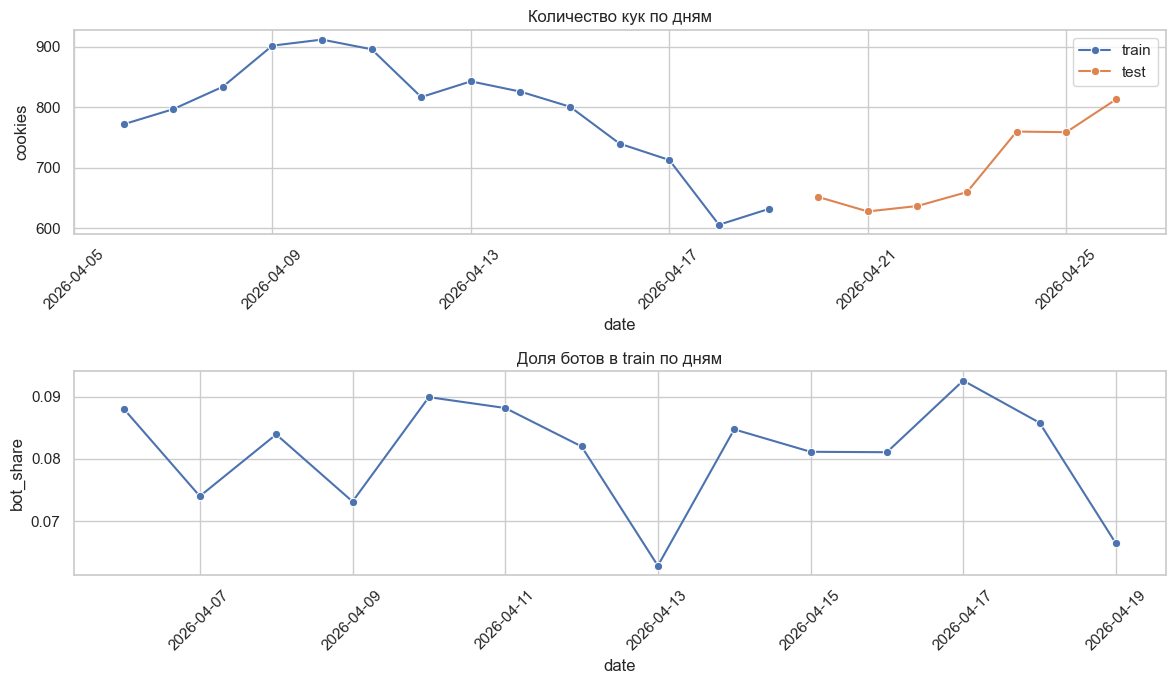

In [10]:
daily_train = train.groupby(train["window_start_ts"].dt.date).agg(
    cookies=("cookie_id", "size"),
    bot_share=("target", "mean"),
).reset_index(names="date")
daily_test = test.groupby(test["window_start_ts"].dt.date).size().reset_index(name="cookies")
daily_test = daily_test.rename(columns={"window_start_ts": "date"})

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
sns.lineplot(data=daily_train, x="date", y="cookies", marker="o", ax=axes[0], label="train")
sns.lineplot(data=daily_test, x="date", y="cookies", marker="o", ax=axes[0], label="test")
axes[0].set_title("Количество кук по дням")
axes[0].tick_params(axis="x", rotation=45)
sns.lineplot(data=daily_train, x="date", y="bot_share", marker="o", ax=axes[1])
axes[1].set_title("Доля ботов в train по дням")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "timeline.png", dpi=160, bbox_inches="tight")
plt.show()

## Типы событий и платформы

In [11]:
event_profile = pd.crosstab(
    events["event_name"],
    events["platform_norm"],
    margins=True,
).sort_values("All", ascending=False)
event_profile

platform_norm,android,desktop,ios,web,All
event_name,,,,,
All,112256,40768,14608,120494,288126
item_view,40992,15589,5396,46109,108086
search_results_view,33928,13004,4469,38397,89798
photo_swipe,13532,4522,1741,13289,33084
favorite_add,7107,2340,951,6898,17296
seller_page_view,6130,2173,752,6487,15542
contact_phone_show,4508,1316,539,3925,10288
login,2308,789,314,2250,5661
contact_chat_open,2494,697,300,2057,5548


## Распределение активности по кукам

In [12]:
cookie_stats = events.groupby("cookie_id").agg(
    event_count=("event_ts", "size"),
    event_type_count=("event_name", "nunique"),
    item_count=("item_id", "nunique"),
    category_count=("item_category", "nunique"),
    query_count=("search_query", "nunique"),
    active_minutes=("event_ts", lambda values: values.dt.floor("min").nunique()),
    duplicate_count=("extra_duplicate", "sum"),
).reset_index()
train_cookie_stats = train[["cookie_id", "target"]].merge(
    cookie_stats,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)
activity_by_target = train_cookie_stats.groupby("target").describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
).T
activity_by_target

target                            0           1
event_count     count  10192.000000  899.000000
                mean      16.869015   29.484983
                std       16.173297   27.515182
                min        1.000000    1.000000
                50%       12.000000   20.000000
...                             ...         ...
duplicate_count 50%        0.000000    0.000000
                90%        1.000000    1.000000
                95%        1.000000    2.000000
                99%        2.000000    3.000000
                max        6.000000    5.000000

[63 rows x 2 columns]

14:55:05 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:55:05 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:55:05 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:55:05 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


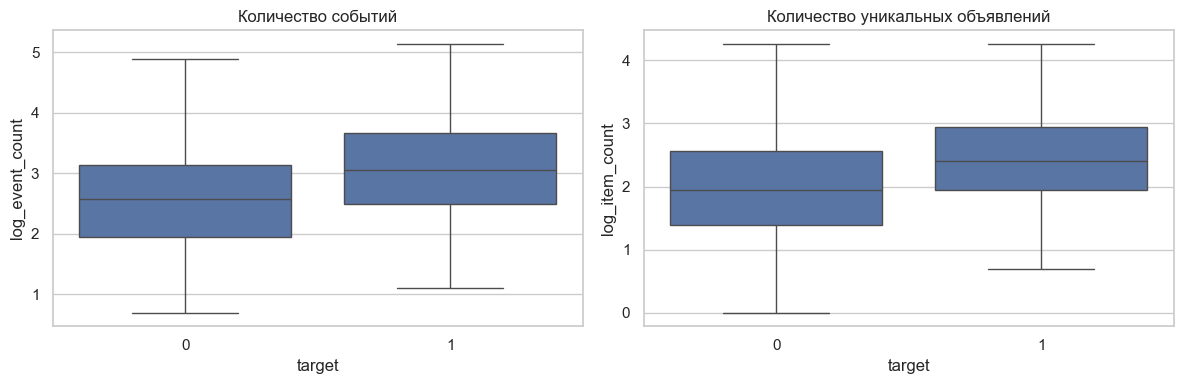

In [13]:
plot_data = train_cookie_stats.copy()
plot_data["log_event_count"] = np.log1p(plot_data["event_count"])
plot_data["log_item_count"] = np.log1p(plot_data["item_count"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=plot_data, x="target", y="log_event_count", ax=axes[0], showfliers=False)
sns.boxplot(data=plot_data, x="target", y="log_item_count", ax=axes[1], showfliers=False)
axes[0].set_title("Количество событий")
axes[1].set_title("Количество уникальных объявлений")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "activity_by_target.png", dpi=160, bbox_inches="tight")
plt.show()

## Дубликаты и одинаковые временные метки

In [14]:
same_time_counts = events.groupby(["cookie_id", "event_ts"]).size()
duplicate_audit = pd.Series({
    "extra_duplicate_rows": int(events["extra_duplicate"].sum()),
    "cookies_with_duplicates": int(
        events.groupby("cookie_id")["extra_duplicate"].any().sum()
    ),
    "cookie_time_groups_with_multiple_events": int((same_time_counts > 1).sum()),
    "max_events_at_same_time": int(same_time_counts.max()),
})
duplicate_audit.to_frame("value")

,value
extra_duplicate_rows,4293
cookies_with_duplicates,3395
cookie_time_groups_with_multiple_events,5754
max_events_at_same_time,3


In [15]:
duplicate_by_target = train_cookie_stats.groupby("target").agg(
    cookies=("cookie_id", "size"),
    cookies_with_duplicates=("duplicate_count", lambda values: int((values > 0).sum())),
    duplicate_mean=("duplicate_count", "mean"),
    duplicate_max=("duplicate_count", "max"),
)
duplicate_by_target

,cookies,cookies_with_duplicates,duplicate_mean,duplicate_max
target,,,,
0,10192,2072,0.250196,6
1,899,288,0.447164,5


## Пересечение сущностей между train и test

Эта таблица используется только для диагностики переносимости. Целевой переменной test у нас нет, и параметры модели по этой таблице не подбираются.

In [16]:
train_ids = set(train["cookie_id"])
test_ids = set(test["cookie_id"])
train_events = events.loc[events["cookie_id"].isin(train_ids)]
test_events = events.loc[events["cookie_id"].isin(test_ids)]

overlap_rows = []
for column in ["item_id", "item_category", "item_location", "search_query", "user_agent"]:
    train_values = set(train_events[column].dropna())
    test_values = set(test_events[column].dropna())
    overlap_rows.append({
        "column": column,
        "train_unique": len(train_values),
        "test_unique": len(test_values),
        "shared_unique": len(train_values & test_values),
        "test_unique_seen_share": len(train_values & test_values) / max(len(test_values), 1),
    })
entity_overlap = pd.DataFrame(overlap_rows)
entity_overlap

,column,train_unique,test_unique,shared_unique,test_unique_seen_share
0,item_id,46953,30902,24926,0.806614
1,item_category,15,15,15,1.000000
2,item_location,40,40,40,1.000000
3,search_query,120,120,120,1.000000
4,user_agent,148,148,148,1.000000


In [17]:
known_items = set(train_events["item_id"].dropna())
test_item_pairs = test_events[["cookie_id", "item_id"]].dropna().drop_duplicates()
test_item_pairs["known_item"] = test_item_pairs["item_id"].isin(known_items)
test_item_coverage = test[["cookie_id"]].merge(
    test_item_pairs.groupby("cookie_id")["known_item"].agg(["any", "mean", "count"]).reset_index(),
    on="cookie_id",
    how="left",
)
test_item_coverage[["any", "mean", "count"]] = test_item_coverage[["any", "mean", "count"]].fillna(0)
item_coverage_summary = pd.Series({
    "test_cookies_with_known_item_share": test_item_coverage["any"].astype(bool).mean(),
    "mean_known_item_share": test_item_coverage["mean"].mean(),
    "test_cookies_without_item_events": int(test_item_coverage["count"].eq(0).sum()),
})
item_coverage_summary.to_frame("value")

,value
test_cookies_with_known_item_share,0.971685
mean_known_item_share,0.807235
test_cookies_without_item_events,65.000000


## Сдвиг числовых признаков между train и test

Для быстрой диагностики используем уже сохранённый базовый набор. Статистика Колмогорова–Смирнова здесь не является критерием удаления признака, а только указывает, какие распределения стоит проверить внимательнее.

In [18]:
basic_path = ARTIFACT_DIR / "feature_sets" / "behavior" / "basic_behavior.pkl"
basic_features = pd.read_pickle(basic_path)
numeric_columns = basic_features.select_dtypes(include=["number", "bool"]).columns
shift_rows = []
for column in numeric_columns:
    train_values = basic_features.loc[basic_features["cookie_id"].isin(train_ids), column].dropna()
    test_values = basic_features.loc[basic_features["cookie_id"].isin(test_ids), column].dropna()
    if len(train_values) and len(test_values):
        shift_rows.append({
            "feature": column,
            "ks_statistic": ks_2samp(train_values, test_values).statistic,
            "train_median": train_values.median(),
            "test_median": test_values.median(),
        })
numeric_shift = pd.DataFrame(shift_rows).sort_values("ks_statistic", ascending=False)
numeric_shift.head(20)

,feature,ks_statistic,train_median,test_median
20,max_search_page,0.025648,4.000000,4.000000
13,events_per_active_minute,0.022553,1.357143,1.375000
50,share_platform_web,0.016622,0.500000,0.555556
14,events_per_span_hour,0.015020,5.897496,5.930807
44,share_favorite_add,0.014874,0.034483,0.031250
49,count_platform_web,0.014827,2.000000,2.000000
26,share_item_view,0.014217,0.363636,0.363636
38,share_contact_chat_open,0.013533,0.000000,0.000000
16,location_nunique,0.013065,5.000000,5.000000
32,share_seller_page_view,0.012917,0.021739,0.027027


## Контроль условий перед моделированием

In [19]:
checks = pd.Series({
    "train_cookie_id_unique": not train["cookie_id"].duplicated().any(),
    "test_cookie_id_unique": not test["cookie_id"].duplicated().any(),
    "train_test_cookie_id_disjoint": not bool(train_ids & test_ids),
    "test_starts_after_train": test["window_start_ts"].min() >= train["window_end_ts"].max(),
    "events_inside_windows": bool(((events["event_ts"] >= events["window_start_ts"]) & (events["event_ts"] < events["window_end_ts"])).all()),
    "captcha_removed": not events["event_name"].eq("captcha_shown").any(),
    "every_cookie_has_events": events["cookie_id"].nunique() == len(metadata),
})
if not checks.all():
    failed = checks.index[~checks].tolist()
    raise ValueError("Не пройдены проверки: " + ", ".join(failed))
checks.to_frame("passed")

,passed
train_cookie_id_unique,True
test_cookie_id_unique,True
train_test_cookie_id_disjoint,True
test_starts_after_train,True
events_inside_windows,True
captcha_removed,True
every_cookie_has_events,True


## Сохранение таблиц

Таблицы сохраняются отдельно, чтобы затем использовать их в итоговом отчёте без повторного чтения исходных событий.

In [20]:
tables_to_save = {
    "data_overview": data_overview,
    "target_summary": target_summary.reset_index(),
    "metadata_missing": metadata_missing.reset_index(names="column"),
    "event_missing": event_missing.reset_index(names="column"),
    "missing_by_event": missing_by_event.reset_index(),
    "window_audit": window_audit.rename_axis("check").reset_index(name="value"),
    "time_summary": time_summary,
    "daily_train": daily_train,
    "daily_test": daily_test,
    "event_profile": event_profile.reset_index(),
    "activity_by_target": activity_by_target.reset_index(),
    "duplicate_audit": duplicate_audit.rename_axis("check").reset_index(name="value"),
    "duplicate_by_target": duplicate_by_target.reset_index(),
    "entity_overlap": entity_overlap,
    "item_coverage_summary": item_coverage_summary.rename_axis("check").reset_index(name="value"),
    "numeric_shift": numeric_shift,
    "checks": checks.rename_axis("check").reset_index(name="passed"),
}
for table_name, table in tables_to_save.items():
    table.to_csv(TABLE_DIR / f"{table_name}.csv", index=False)

pd.Series({"saved_tables": len(tables_to_save), "folder": str(TABLE_DIR)}).to_frame("value")

,value
saved_tables,17
folder,C:\Users\Kolya\Desktop\ОтборНаСтажки\Авито\Tes...


## Выводы после запуска

1. В обучающей выборке 11 091 кука, в тестовой — 4 909. Положительный класс содержит 899 кук, или 8,11% train. При обучении нельзя ориентироваться на точность классификации: она будет завышена из-за дисбаланса. Основной критерий — Precision при Recall не ниже 70%.
2. В таблицах train и test пропусков нет. Пропуски в событиях в основном структурные: например, запрос и номер страницы заполнены только для просмотра выдачи, а `item_id` отсутствует у выдачи и входа. Такие пропуски несут информацию о типе действия, поэтому их доли используются как отдельные признаки.
3. Из 328 905 исходных событий 40 779 лежат вне разрешённых окон и исключены. Все 7 928 показов капчи находятся вне окон; после подготовки событий их нет. Правая граница окна не включается.
4. Train охватывает окна с 6 по 19 апреля, test начинается 20 апреля. Случайное перемешивание нарушило бы порядок данных, поэтому качество далее оценивается только на последовательных временных разбиениях.
5. Боты в среднем активнее: 29,5 события на куку против 16,9 у остальных. Одного счётчика недостаточно из-за сильного пересечения распределений, но объём, плотность и ритм действий должны быть полезны совместно. Скошенные счётчики дополнительно представлены логарифмами.
6. Внутри окон найдено 4 293 лишних копии строк. Среднее число дублей у ботов выше: 0,447 против 0,250. Дубликаты не удаляются молча — их количество и доля становятся признаками.
7. Есть 5 754 группы с несколькими событиями в одну секунду. Порядок таких событий неизвестен, поэтому последовательностные признаки должны рассматривать их как один неупорядоченный момент.
8. Сдвиг базовых числовых признаков между train и test небольшой: максимальная статистика Колмогорова–Смирнова равна 0,0256 для глубины просмотра выдачи. Категории, регионы, запросы и строки клиента полностью покрываются train.
9. Для 97,17% тестовых кук встречается хотя бы одно объявление из train, а средняя доля известных объявлений равна 80,72%. Это обосновывает отдельную проверку признаков прошлой истории объявлений. Для новых объявлений обязательно остаётся сглаженное значение по train, а не пустое значение или идентификатор.
10. Все итоговые проверки пройдены: идентификаторы кук уникальны и не пересекаются, тест идёт после train, события находятся внутри окон, капча исключена, у каждой куки есть события. Данные готовы к временной перекрёстной проверке моделей.